# Kalos Pretrain Trace EDA for Quantum/QUBO Instance Design

This notebook analyzes only **Pretrain** jobs from the Kalos production trace from the Shanghai AI Laboratory Acme data center. The goal is to understand how real LLM pretraining workloads can be converted into reduced quantum/QUBO scheduling instances.

The main modeling issue is GPU scale. Kalos has 2,416 A100 GPUs, while pretraining jobs can request hundreds or more than one thousand GPUs. Directly encoding raw GPU capacity in a QUBO increases the number of slack variables and couplers in the GPU-capacity penalty. A coarser resource unit can reduce the QUBO while preserving the structure of large LLM pretraining jobs.

The notebook compares two pretraining subsets:

- **All Pretrain jobs**: every job labeled `Pretrain`, regardless of final state.
- **Completed Pretrain jobs**: only `Pretrain` jobs with state `COMPLETED`, used as the cleanest proxy for actual completed workload demand.

Questions covered here:

- How large are Pretrain GPU requirements?
- How expensive is it to model Pretrain capacity using raw GPUs, nodes, or GPU blocks?
- How many Pretrain jobs arrive per day and per hour?
- What hourly energy profile does the historical Pretrain schedule imply?
- Does the trace provide explicit start-time restrictions, deadlines, or flexibility windows?
- Which GPU abstraction is most appropriate for quantum/QUBO experiments?


In [1]:
from __future__ import annotations

from math import ceil, floor, log2
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TRACE_PATH = Path("/Users/juanparrado/Downloads/trace_kalos.csv")
TOTAL_GPUS = 2416
GPUS_PER_NODE = 8
BLOCK_GPU_OPTIONS = [32, 64, 96, 128, 256]
A100_TDP_KW = 0.4
KALOS_PUE = 1.25

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


## 1. Load and Prepare Pretrain Jobs

The trace timestamps are parsed as UTC datetimes. The `duration` column is interpreted as seconds based on the examples in the raw file, so we convert it to hours for analysis.

All analysis below filters the raw trace to `type == "Pretrain"`. When relevant, plots compare all Pretrain jobs against completed Pretrain jobs.


In [2]:
raw = pd.read_csv(TRACE_PATH)

# Keep only Pretrain rows for this notebook.
df = raw[raw["type"] == "Pretrain"].copy()

for column in ["submit_time", "start_time", "end_time", "fail_time", "stop_time"]:
    df[column] = pd.to_datetime(df[column], utc=True, errors="coerce")

df["duration_hours"] = df["duration"] / 3600.0
df["queue_seconds"] = df["queue"]
df["queue_hours"] = df["queue_seconds"] / 3600.0
df["submit_day"] = df["submit_time"].dt.floor("D")
df["submit_hour"] = df["submit_time"].dt.hour
df["submit_date"] = df["submit_time"].dt.date
df["node_units"] = df["gpu_num"] / GPUS_PER_NODE

pretrain = df.copy()
pretrain_completed = df[df["state"] == "COMPLETED"].copy()

pretrain.shape, pretrain_completed.shape, pretrain.head()


((641, 24),
 (183, 24),
               job_id   user  node_num  gpu_num  cpu_num  mem_per_pod_GB  shared_mem_per_pod      type      state               submit_time  \
 10  dlc1l25dz8p9g09x  u212a        16      128     1920            1000               100.0  Pretrain  CANCELLED 2023-05-17 13:02:06+00:00   
 27  dlc729ngkzgal94e  ud094        16      128     1920            1000               100.0  Pretrain  COMPLETED 2023-05-18 03:42:17+00:00   
 29  dlc1n94flwxz5s64  ud094        32      256     3840            1000               100.0  Pretrain  CANCELLED 2023-05-18 05:32:05+00:00   
 30  dlckyr9xg7j917kl  ud094        32      256     3840            1000               100.0  Pretrain  COMPLETED 2023-05-18 05:38:19+00:00   
 31  dlc1f7omx09ga7i5  ud094        32      256     3840            1000               100.0  Pretrain  COMPLETED 2023-05-18 05:57:13+00:00   
 
                   start_time                  end_time fail_time                 stop_time  duration  queue  gpu_ti

In [3]:
summary = pd.DataFrame({
    "subset": ["pretrain_all", "pretrain_completed"],
    "jobs": [len(pretrain), len(pretrain_completed)],
    "start_date": [pretrain["submit_time"].min(), pretrain_completed["submit_time"].min()],
    "end_date": [pretrain["submit_time"].max(), pretrain_completed["submit_time"].max()],
    "mean_gpu_num": [pretrain["gpu_num"].mean(), pretrain_completed["gpu_num"].mean()],
    "median_gpu_num": [pretrain["gpu_num"].median(), pretrain_completed["gpu_num"].median()],
    "mean_duration_hours": [pretrain["duration_hours"].mean(), pretrain_completed["duration_hours"].mean()],
    "median_duration_hours": [pretrain["duration_hours"].median(), pretrain_completed["duration_hours"].median()],
})
summary


,subset,jobs,start_date,end_date,mean_gpu_num,median_gpu_num,mean_duration_hours,median_duration_hours
0,pretrain_all,641,2023-05-17 13:02:06+00:00,2023-08-15 14:46:30+00:00,523.943838,512.0,4.532564,0.191389
1,pretrain_completed,183,2023-05-18 03:42:17+00:00,2023-08-15 12:28:07+00:00,532.327869,512.0,5.761588,0.097500


In [4]:
pretrain_state_summary = (
    pretrain["state"]
    .value_counts()
    .rename_axis("state")
    .reset_index(name="jobs")
)
pretrain_state_summary["share"] = pretrain_state_summary["jobs"] / pretrain_state_summary["jobs"].sum()
pretrain_state_summary


,state,jobs,share
0,CANCELLED,408,0.636505
1,COMPLETED,183,0.285491
2,FAILED,49,0.076443
3,RUNNING,1,0.001560


## 2. Pretrain GPU Requirement Analysis

For QUBO experiments, the central question is the unit used in the GPU-capacity constraint.

Candidate representations:

- **Raw GPUs**: most realistic, but capacity is 2,416 and slack bits are larger.
- **Node units**: 1 unit = 8 GPUs. This maps directly to Kalos hardware: 302 nodes.
- **Block units**: 1 unit = 96 GPUs = 12 nodes. This maps the smallest pretraining job to 1 unit and makes the QUBO much smaller.

For quantum experiments, the unit does not need to be the same as the operational MILP. It should preserve the scheduling conflict while keeping the binary encoding small enough to test.


In [5]:
def gpu_distribution(frame: pd.DataFrame, label: str) -> pd.Series:
    values = frame["gpu_num"]
    return pd.Series({
        "label": label,
        "jobs": len(frame),
        "min": values.min(),
        "p10": values.quantile(0.10),
        "p25": values.quantile(0.25),
        "median": values.quantile(0.50),
        "mean": values.mean(),
        "p75": values.quantile(0.75),
        "p90": values.quantile(0.90),
        "p95": values.quantile(0.95),
        "p99": values.quantile(0.99),
        "max": values.max(),
    })

frames = {
    "pretrain_all": pretrain,
    "pretrain_completed": pretrain_completed,
}

gpu_summary = pd.DataFrame([gpu_distribution(frame, label) for label, frame in frames.items()])
gpu_summary


,label,jobs,min,p10,p25,median,mean,p75,p90,p95,p99,max
0,pretrain_all,641,96,256.0,256.0,512.0,523.943838,512.0,1024.0,1024.0,1024.0,1024
1,pretrain_completed,183,96,256.0,256.0,512.0,532.327869,512.0,1024.0,1024.0,1024.0,1024


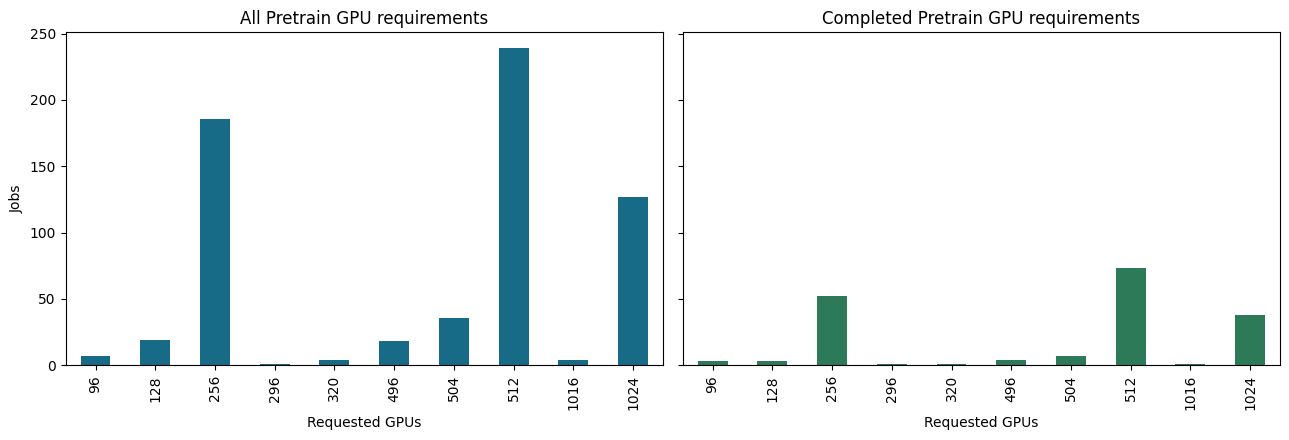

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

pretrain["gpu_num"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#176b87")
axes[0].set_title("All Pretrain GPU requirements")
axes[0].set_xlabel("Requested GPUs")
axes[0].set_ylabel("Jobs")

pretrain_completed["gpu_num"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#2c7a57")
axes[1].set_title("Completed Pretrain GPU requirements")
axes[1].set_xlabel("Requested GPUs")
axes[1].set_ylabel("Jobs")

plt.tight_layout()
plt.show()


## 3. Nodes vs Blocks for QUBO Capacity

The conservative scaling rule for QUBO experiments is:

$$
\text{scaled job demand} = \left\lceil \frac{\text{job GPUs}}{\text{unit GPUs}} \right\rceil
$$

$$
\text{scaled cluster capacity} = \left\lfloor \frac{2416}{\text{unit GPUs}} \right\rfloor
$$

This is intentionally conservative:

- we never underestimate a job's requirement;
- we never invent extra cluster capacity;
- all QUBO resource quantities stay integer.

Decimals are technically possible as QUBO coefficients, but they are not recommended for the capacity/slack constraint because integer slack would no longer exactly represent unused capacity.


In [7]:
def scaled_gpu_report(frame: pd.DataFrame, unit_gpu: int, label: str) -> pd.Series:
    demand = np.ceil(frame["gpu_num"] / unit_gpu).astype(int)
    capacity = floor(TOTAL_GPUS / unit_gpu)
    equivalent_gpu = demand * unit_gpu
    relative_overstatement = (equivalent_gpu - frame["gpu_num"]) / frame["gpu_num"].replace(0, np.nan)
    return pd.Series({
        "unit": label,
        "unit_gpu": unit_gpu,
        "capacity_units": capacity,
        "slack_bits_per_cluster_time": ceil(log2(capacity + 1)) if capacity > 0 else 1,
        "min_demand": demand.min(),
        "median_demand": demand.median(),
        "mean_demand": demand.mean(),
        "max_demand": demand.max(),
        "mean_relative_overstatement": relative_overstatement.mean(),
        "max_relative_overstatement": relative_overstatement.max(),
        "jobs_exceeding_capacity": int((demand > capacity).sum()),
    })

unit_rows = []
unit_rows.append(scaled_gpu_report(pretrain_completed, GPUS_PER_NODE, "node: 8 GPUs"))
for unit_gpu in BLOCK_GPU_OPTIONS:
    unit_rows.append(scaled_gpu_report(pretrain_completed, unit_gpu, f"block: {unit_gpu} GPUs"))

scaling_summary = pd.DataFrame(unit_rows)
scaling_summary


,unit,unit_gpu,capacity_units,slack_bits_per_cluster_time,min_demand,median_demand,mean_demand,max_demand,mean_relative_overstatement,max_relative_overstatement,jobs_exceeding_capacity
0,node: 8 GPUs,8,302,9,12,64.0,66.540984,128,0.000000,0.000000,0
1,block: 32 GPUs,32,75,7,3,16.0,16.661202,32,0.001798,0.081081,0
2,block: 64 GPUs,64,37,6,2,8.0,8.338798,16,0.007263,0.333333,0
3,block: 96 GPUs,96,25,5,1,6.0,6.043716,11,0.111991,0.500000,0
4,block: 128 GPUs,128,18,5,1,4.0,4.174863,8,0.009537,0.333333,0
5,block: 256 GPUs,256,9,4,1,2.0,2.109290,4,0.052337,1.666667,0


In [8]:
# Per-GPU-size impact of the preferred 96-GPU block abstraction.
preferred_unit_gpu = 96
block_impact = (
    pretrain_completed.groupby("gpu_num")
    .size()
    .rename("jobs")
    .reset_index()
)
block_impact["node_units"] = block_impact["gpu_num"] / GPUS_PER_NODE
block_impact["block_96_units"] = np.ceil(block_impact["gpu_num"] / preferred_unit_gpu).astype(int)
block_impact["gpu_equivalent_after_scaling"] = block_impact["block_96_units"] * preferred_unit_gpu
block_impact["relative_overstatement"] = (
    block_impact["gpu_equivalent_after_scaling"] - block_impact["gpu_num"]
) / block_impact["gpu_num"]
block_impact.sort_values("gpu_num")


,gpu_num,jobs,node_units,block_96_units,gpu_equivalent_after_scaling,relative_overstatement
0,96,3,12.0,1,96,0.000000
1,128,3,16.0,2,192,0.500000
2,256,52,32.0,3,288,0.125000
3,296,1,37.0,4,384,0.297297
4,320,1,40.0,4,384,0.200000
5,496,4,62.0,6,576,0.161290
6,504,7,63.0,6,576,0.142857
7,512,73,64.0,6,576,0.125000
8,1016,1,127.0,11,1056,0.039370
9,1024,38,128.0,11,1056,0.031250


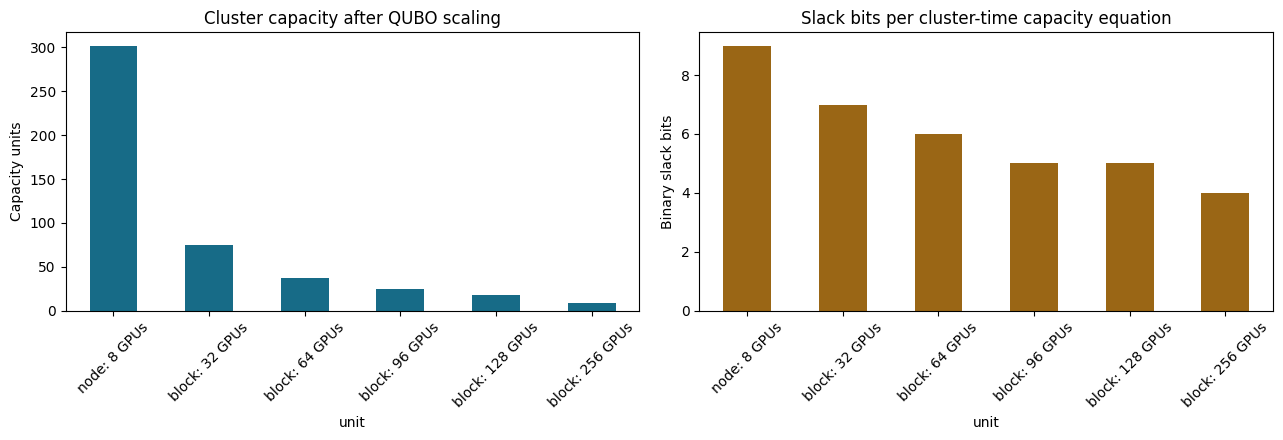

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

scaling_summary.plot(
    x="unit",
    y="capacity_units",
    kind="bar",
    ax=axes[0],
    color="#176b87",
    legend=False,
)
axes[0].set_title("Cluster capacity after QUBO scaling")
axes[0].set_ylabel("Capacity units")
axes[0].tick_params(axis="x", rotation=45)

scaling_summary.plot(
    x="unit",
    y="slack_bits_per_cluster_time",
    kind="bar",
    ax=axes[1],
    color="#9a6615",
    legend=False,
)
axes[1].set_title("Slack bits per cluster-time capacity equation")
axes[1].set_ylabel("Binary slack bits")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


### Interpretation: Nodes vs 96-GPU Blocks

For QUBO experiments, 96-GPU blocks are attractive because the minimum pretraining job becomes exactly 1 unit:

$$
96\ \text{GPUs} = 12\ \text{nodes} = 1\ \text{block}
$$

This coarsening is not intended for full operational realism. It is a quantum abstraction: it reduces the number of slack bits and keeps capacity/demand integer while preserving the fact that pretraining jobs are large, capacity-consuming objects.

The trade-off is conservatism. A 128-GPU job becomes 2 blocks, which is 192 GPU-equivalent. This overstates its GPU consumption but avoids fractional capacity and keeps the QUBO clean.


## 4. Pretrain Job Arrival Volume by Day and Hour

For scheduling, arrival intensity matters because it determines how many jobs may compete inside a rolling horizon. We analyze Pretrain submissions by day and hour, comparing all Pretrain jobs against completed Pretrain jobs.


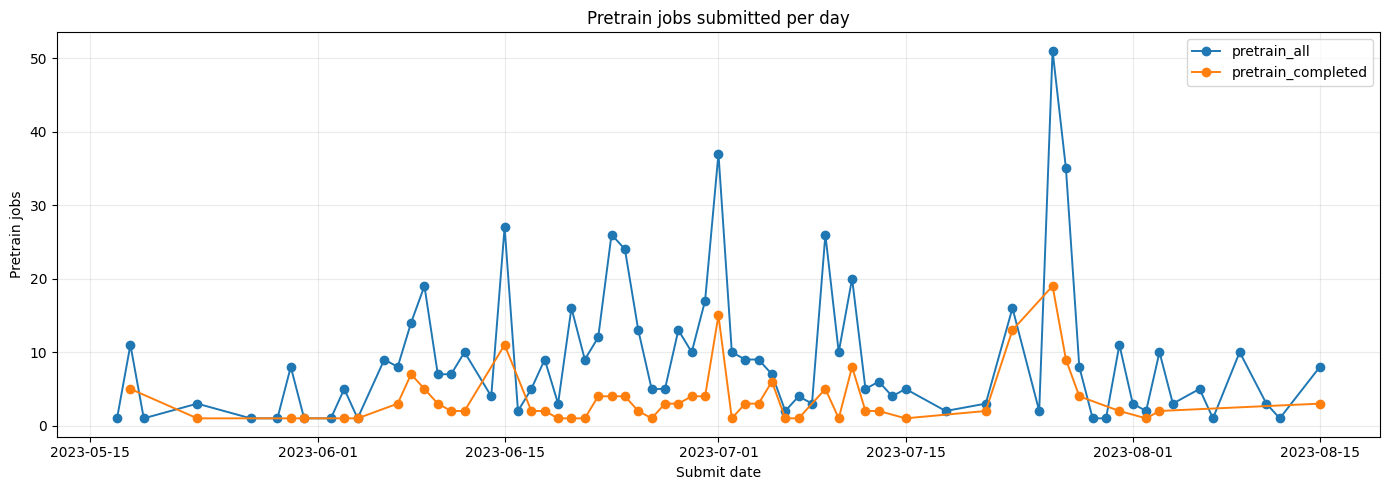

,count,mean,std,min,25%,50%,75%,90%,max
series,,,,,,,,,
pretrain_all,70.0,9.16,9.50,1.0,3.0,7.0,10.75,20.4,51.0
pretrain_completed,49.0,3.73,3.85,1.0,1.0,2.0,4.00,8.2,19.0


In [10]:
def daily_counts(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    out = frame.groupby("submit_date").size().rename("jobs").reset_index()
    out["series"] = label
    return out

daily = pd.concat([
    daily_counts(pretrain, "pretrain_all"),
    daily_counts(pretrain_completed, "pretrain_completed"),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(14, 5))
for label, group in daily.groupby("series"):
    ax.plot(pd.to_datetime(group["submit_date"]), group["jobs"], marker="o", linewidth=1.4, label=label)
ax.set_title("Pretrain jobs submitted per day")
ax.set_xlabel("Submit date")
ax.set_ylabel("Pretrain jobs")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

daily_summary = daily.groupby("series")["jobs"].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(2)
daily_summary


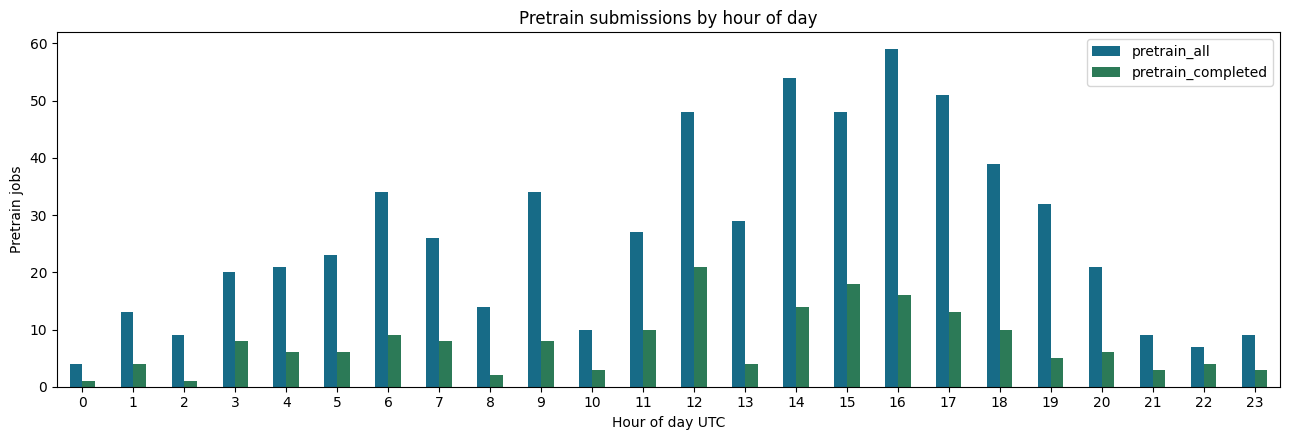

,pretrain_all,pretrain_completed
submit_hour,,
0,4,1
1,13,4
2,9,1
3,20,8
4,21,6
5,23,6
6,34,9
7,26,8
8,14,2


In [11]:
hourly_profile = pd.DataFrame({
    "pretrain_all": pretrain.groupby("submit_hour").size(),
    "pretrain_completed": pretrain_completed.groupby("submit_hour").size(),
}).fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(13, 4.5))
hourly_profile.plot(kind="bar", ax=ax, color=["#176b87", "#2c7a57"])
ax.set_title("Pretrain submissions by hour of day")
ax.set_xlabel("Hour of day UTC")
ax.set_ylabel("Pretrain jobs")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

hourly_profile


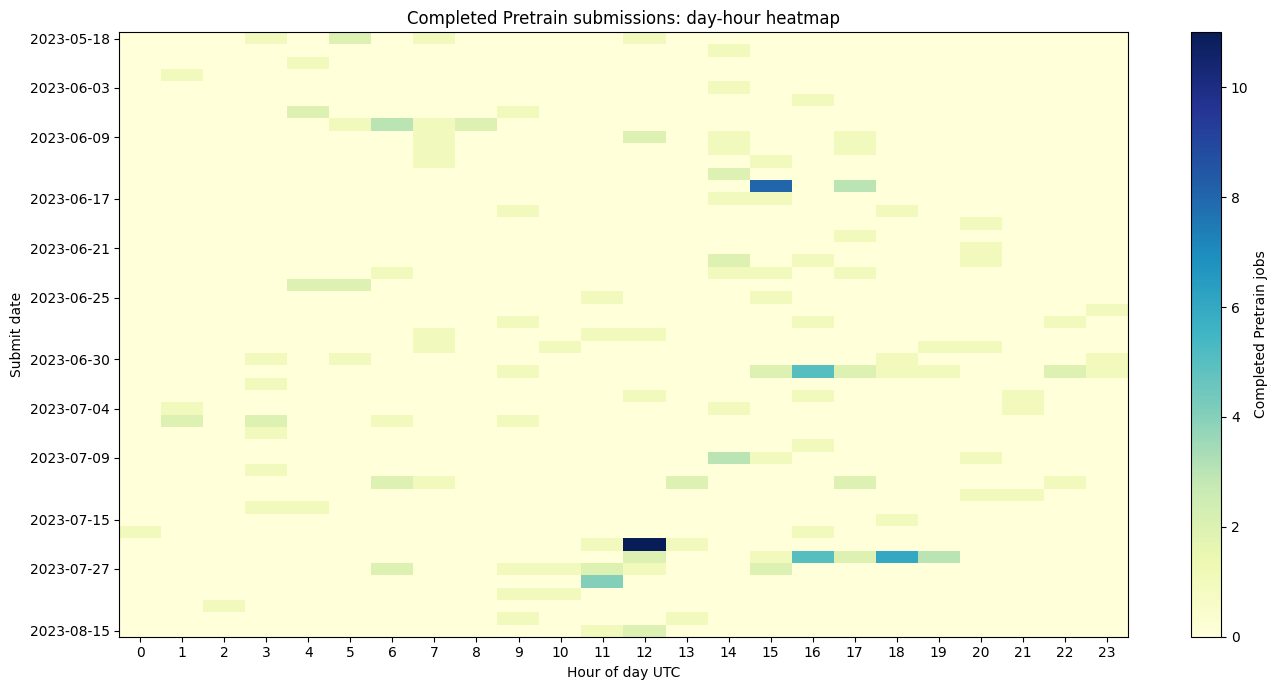

In [12]:
# Day-hour heatmap for completed Pretrain jobs.
pretrain_completed_heatmap = (
    pretrain_completed
    .groupby(["submit_date", "submit_hour"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(24), fill_value=0)
)

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(pretrain_completed_heatmap.values, aspect="auto", cmap="YlGnBu")
ax.set_title("Completed Pretrain submissions: day-hour heatmap")
ax.set_xlabel("Hour of day UTC")
ax.set_ylabel("Submit date")
ax.set_xticks(range(24))
# Show a subset of dates so the axis remains readable.
y_ticks = np.linspace(0, len(pretrain_completed_heatmap.index) - 1, min(12, len(pretrain_completed_heatmap.index))).astype(int)
ax.set_yticks(y_ticks)
ax.set_yticklabels([str(pretrain_completed_heatmap.index[i]) for i in y_ticks])
fig.colorbar(im, ax=ax, label="Completed Pretrain jobs")
plt.tight_layout()
plt.show()


## 5. Historical Pretrain Energy Consumption per Hour

The trace contains the historical execution interval of each job. We can therefore estimate the hourly energy consumed by the observed Pretrain schedule.

Assumptions used in this section:

- each requested A100 GPU is modeled at its 400 W TDP;
- hourly IT energy is computed from the overlap between each job execution interval and each hourly bucket;
- facility energy applies Kalos PUE as a constant multiplier: `facility_energy = IT_energy * 1.25`;
- this is an estimate of the historical schedule, not an optimized schedule.

We report both all started Pretrain jobs and completed Pretrain jobs. Failed or cancelled jobs can still consume energy while they are running, so the all-Pretrain view is useful for infrastructure load; completed Pretrain is the cleaner workload subset for controlled optimization experiments.


In [13]:
def hourly_energy_profile(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    """Estimate hourly GPU and energy consumption from historical execution intervals."""

    rows = []
    jobs = frame.copy()
    jobs["effective_end_time"] = jobs["end_time"].combine_first(jobs["stop_time"]).combine_first(jobs["fail_time"])
    jobs = jobs[jobs["start_time"].notna() & jobs["effective_end_time"].notna() & (jobs["effective_end_time"] > jobs["start_time"])]

    if jobs.empty:
        return pd.DataFrame(columns=[
            "hour", "series", "active_gpu_hours", "avg_active_gpus", "it_energy_mwh", "facility_energy_mwh"
        ])

    first_hour = jobs["start_time"].min().floor("h")
    last_hour = jobs["effective_end_time"].max().ceil("h")
    hours = pd.date_range(first_hour, last_hour, freq="h", inclusive="left")

    for hour_start in hours:
        hour_end = hour_start + pd.Timedelta(hours=1)
        active = jobs[(jobs["start_time"] < hour_end) & (jobs["effective_end_time"] > hour_start)]
        gpu_hours = 0.0
        for job in active.itertuples(index=False):
            overlap_start = max(job.start_time, hour_start)
            overlap_end = min(job.effective_end_time, hour_end)
            overlap_hours = (overlap_end - overlap_start).total_seconds() / 3600.0
            gpu_hours += float(job.gpu_num) * overlap_hours

        it_energy_mwh = gpu_hours * A100_TDP_KW / 1000.0
        rows.append({
            "hour": hour_start,
            "series": label,
            "active_gpu_hours": gpu_hours,
            "avg_active_gpus": gpu_hours,
            "it_energy_mwh": it_energy_mwh,
            "facility_energy_mwh": it_energy_mwh * KALOS_PUE,
        })

    return pd.DataFrame(rows)

energy_hourly = pd.concat([
    hourly_energy_profile(pretrain, "pretrain_all"),
    hourly_energy_profile(pretrain_completed, "pretrain_completed"),
], ignore_index=True)

energy_summary = (
    energy_hourly
    .groupby("series")[["active_gpu_hours", "it_energy_mwh", "facility_energy_mwh"]]
    .agg(["sum", "mean", "max"])
    .round(4)
)
energy_summary


active_gpu_hours                   it_energy_mwh                 facility_energy_mwh               
                                sum      mean     max           sum    mean     max                 sum    mean    max
series                                                                                                                
pretrain_all           1.378184e+06  637.4580  1152.0      551.2737  0.2550  0.4608            689.0921  0.3187  0.576
pretrain_completed     4.376840e+05  203.9534  1024.0      175.0736  0.0816  0.4096            218.8420  0.1020  0.512

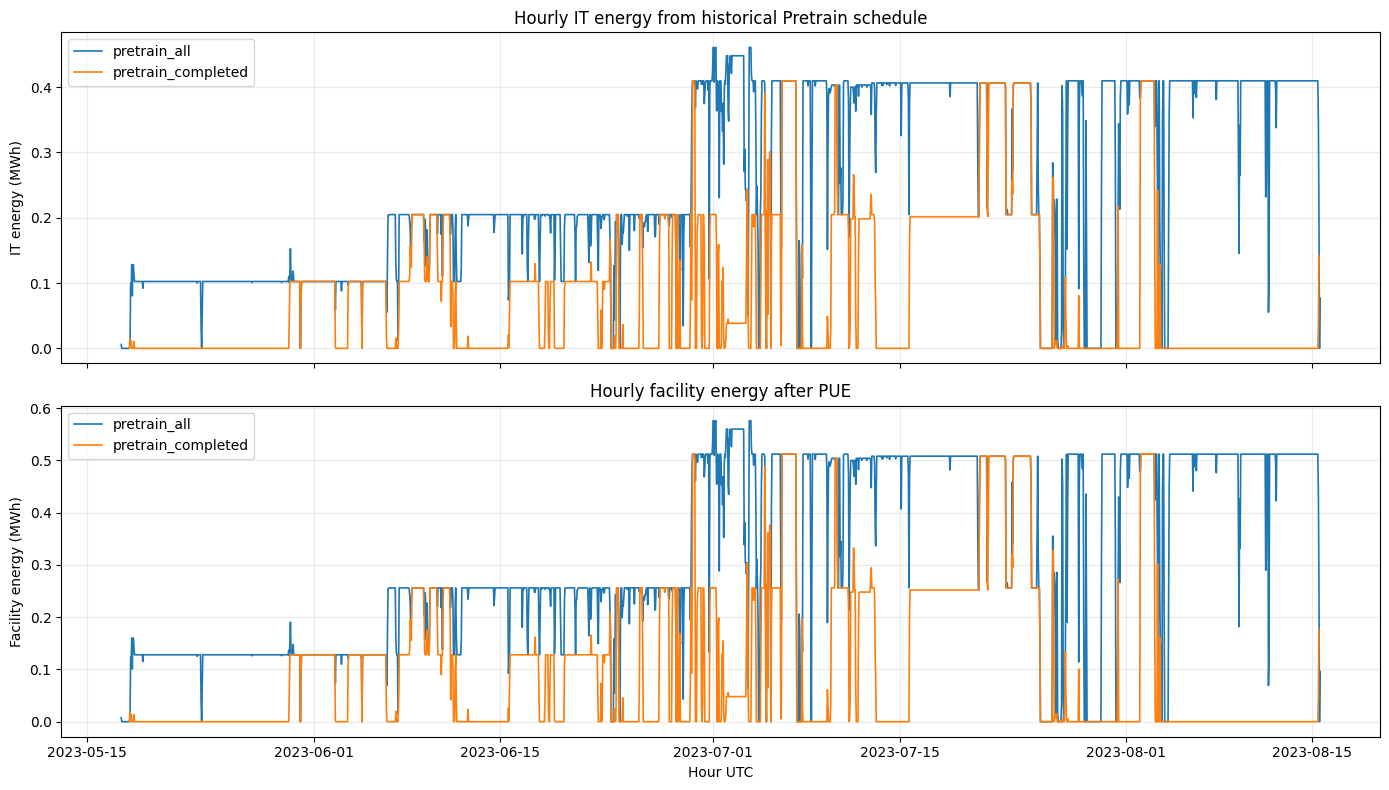

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for label, group in energy_hourly.groupby("series"):
    axes[0].plot(group["hour"], group["it_energy_mwh"], linewidth=1.2, label=label)
axes[0].set_title("Hourly IT energy from historical Pretrain schedule")
axes[0].set_ylabel("IT energy (MWh)")
axes[0].legend()
axes[0].grid(alpha=0.25)

for label, group in energy_hourly.groupby("series"):
    axes[1].plot(group["hour"], group["facility_energy_mwh"], linewidth=1.2, label=label)
axes[1].set_title("Hourly facility energy after PUE")
axes[1].set_xlabel("Hour UTC")
axes[1].set_ylabel("Facility energy (MWh)")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()


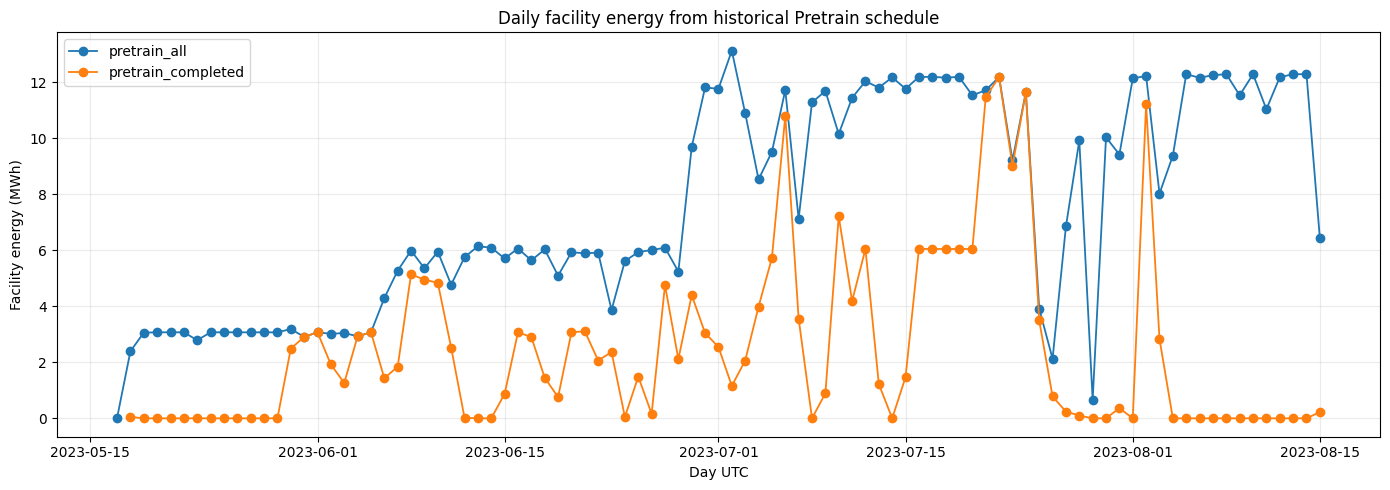

it_energy_mwh                                                          facility_energy_mwh                                             \
                           count   mean    std    min    25%    50%    75%    90%     max               count   mean    std    min    25%    50%     75%   
series                                                                                                                                                     
pretrain_all                91.0  6.058  3.041  0.006  3.114  4.915  9.375  9.754  10.501                91.0  7.572  3.801  0.007  3.892  6.144  11.719   
pretrain_completed          90.0  1.945  2.454  0.000  0.000  1.152  2.718  4.838   9.748                90.0  2.432  3.067  0.000  0.000  1.441   3.398   

                                    
                       90%     max  
series                              
pretrain_all        12.192  13.126  
pretrain_completed   6.048  12.185

In [15]:
daily_energy = (
    energy_hourly
    .assign(day=lambda x: x["hour"].dt.date)
    .groupby(["series", "day"])[["it_energy_mwh", "facility_energy_mwh"]]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for label, group in daily_energy.groupby("series"):
    ax.plot(pd.to_datetime(group["day"]), group["facility_energy_mwh"], marker="o", linewidth=1.3, label=label)
ax.set_title("Daily facility energy from historical Pretrain schedule")
ax.set_xlabel("Day UTC")
ax.set_ylabel("Facility energy (MWh)")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

daily_energy.groupby("series")[["it_energy_mwh", "facility_energy_mwh"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(3)


## 6. Start-Time Restrictions in the Pretrain Trace

The trace provides historical timing fields:

- `submit_time`: when the job was submitted;
- `start_time`: when the production scheduler actually started it;
- `end_time`, `fail_time`, `stop_time`: terminal timestamps depending on state;
- `queue`: observed waiting time before start, in seconds.

It does **not** provide explicit scheduling restrictions such as:

- latest start time;
- deadline;
- user-provided flexibility window;
- SLA or priority class usable as a hard constraint.

For instance generation, the safest interpretation is:

$$
\text{earliest start} = \text{submit time}
$$

The observed `start_time` is not a restriction. It is the result of Kalos' historical scheduler and queueing conditions. We can use it as a baseline or calibration signal, but not as a hard latest-start constraint.

Therefore, if we want flexible scheduling instances from Kalos, we must define flexibility ourselves. Options include:

1. **Replay mode**: preserve observed submit order and start times as a baseline schedule.
2. **Release-plus-window mode**: set earliest start to submit time and assign a synthetic latest start based on duration, queue-time distribution, or business assumptions.
3. **Rolling-horizon mode**: aggregate submitted Pretrain jobs into hourly forecast buckets and schedule only the next 3-4 hours.

For the quantum/QUBO experiments, release-plus-window mode is usually the most useful because it creates controlled flexibility while still using real Pretrain job size and duration distributions.


In [16]:
queue_check = (
    pretrain[pretrain["start_time"].notna()]
    .assign(
        queue_seconds_from_timestamps=lambda x: (x["start_time"] - x["submit_time"]).dt.total_seconds(),
        queue_difference_seconds=lambda x: x["queue"] - (x["start_time"] - x["submit_time"]).dt.total_seconds(),
    )
)

queue_summary = (
    queue_check
    .groupby("state")[["queue_hours", "queue_seconds_from_timestamps", "queue_difference_seconds"]]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
)
queue_summary


queue_hours                                                                                           queue_seconds_from_timestamps              \
                count      mean       std       min       25%       50%       75%       90%       95%       max                         count        mean   
state                                                                                                                                                       
CANCELLED       408.0  0.039737  0.233962  0.002222  0.003056  0.003611  0.007222  0.026194  0.068667  3.176944                         408.0  143.053922   
COMPLETED       183.0  0.014364  0.043151  0.001944  0.003056  0.003611  0.004722  0.018944  0.056722  0.300833                         183.0   51.710383   
FAILED           49.0  0.010527  0.013492  0.002222  0.003056  0.003889  0.014444  0.026556  0.040778  0.068889                          49.0   37.897959   
RUNNING           1.0  0.004167       NaN  0.004167  0.004167  0.004167  0.004167  0.004167  0.004167  0.004167                           1.0   15.000000   

                                                                    queue_difference_seconds                                               
                  std   min   25%   50%   75%   90%    95%      max                    count mean  std  min  25%  50%  75%  90%  95%  max  
state                                                                                                                                      
CANCELLED  842.261739   8.0  11.0  13.0  26.0  94.3  247.2  11437.0                    408.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
COMPLETED  155.344029   7.0  11.0  13.0  17.0  68.2  204.2   1083.0                    183.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
FAILED      48.570501   8.0  11.0  14.0  52.0  95.6  146.8    248.0                     49.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  
RUNNING           NaN  15.0  15.0  15.0  15.0  15.0   15.0     15.0                      1.0  0.0  NaN  0.0  0.0  0.0  0.0  0.0  0.0  0.0

## 7. Recommendation for Pretrain QUBO Instances

For Kalos Pretrain QUBO experiments, use a separate quantum abstraction rather than raw GPUs:

```text
1 QUBO GPU block = 96 A100 GPUs = 12 Kalos nodes
```

Then compute:

```text
block_required = ceil(gpu_num / 96)
block_capacity = floor(2416 / 96) = 25
```

This representation is conservative, integer-valued, and aligned with the minimum observed Pretrain job size. It reduces GPU capacity from 2,416 raw GPUs or 302 nodes to 25 QUBO capacity units, cutting slack bits per cluster-time equation to:

$$
\lceil \log_2(25+1) \rceil = 5
$$

This is appropriate only for the quantum/QUBO track. The MILP or operational model can still use raw GPUs or node units for higher realism.
